# FlipItNews — News Article Category Classification

**Business context:** FlipItNews wants to automatically categorize news articles pulled from its internal database into topics — Politics, Technology, Sports, Business, and Entertainment — so that smart content discovery can surface the right articles to the right readers.

**Objective:** Build, evaluate, and compare at least three (here, four) multi-class text classification models — Naive Bayes, Decision Tree, K-Nearest Neighbors, and Random Forest — using classical NLP preprocessing (stopword removal, tokenization, lemmatization) and two vectorization schemes (Bag of Words and TF-IDF).

**Dataset:** `flipitnews-data.csv` — 2 columns: `Article` (raw news text) and `Category` (the label).


## 1. Import Libraries and Load the Dataset

In [1]:
# Core libraries
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# One-time NLTK resource downloads (safe to re-run; will no-op if already present)
for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ML
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Error loading stopwords: Security Violation
[nltk_data]     [pathsec.urlopen]: refusing a proxied fetch of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be SSRF-safe, opt in via
[nltk_data]     NLTK_ALLOW_PROXIED_URLOPEN=1 or
[nltk_data]     nltk.pathsec.ALLOW_PROXIED_FETCH=True.
[nltk_data] Error loading punkt: Security Violation [pathsec.urlopen]:
[nltk_data]     refusing a proxied fetch of
[nltk_data]     'https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/index.xml'. A configured proxy performs the
[nltk_data]     egress, so NLTK cannot pin the validated IP and SSRF
[nltk_data]     protection cannot be enforced (CWE-918). If and only
[nltk_data]     if the proxy is trusted to be S

In [2]:
# Load the dataset
df = pd.read_csv('flipitnews-data.csv')
df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


## 2. Preliminary / Exploratory Analysis

In [3]:
print(f"Shape of the dataset: {df.shape}")
print(f"Number of news articles: {df.shape[0]}")
print(f"Columns: {list(df.columns)}")

Shape of the dataset: (2225, 2)
Number of news articles: 2225
Columns: ['Category', 'Article']


In [4]:
# Missing values and duplicate rows
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nFully duplicated rows: {df.duplicated().sum()}")

Missing values per column:
Category    0
Article     0
dtype: int64

Fully duplicated rows: 99


In [5]:
# Distribution of articles across categories
category_counts = df['Category'].value_counts()
print("News articles per category:")
print(category_counts)
print(f"\nMost common category: {category_counts.idxmax()} ({category_counts.max()} articles)")
print(f"Technology category count: {category_counts['Technology']}")

News articles per category:
Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64

Most common category: Sports (511 articles)
Technology category count: 401


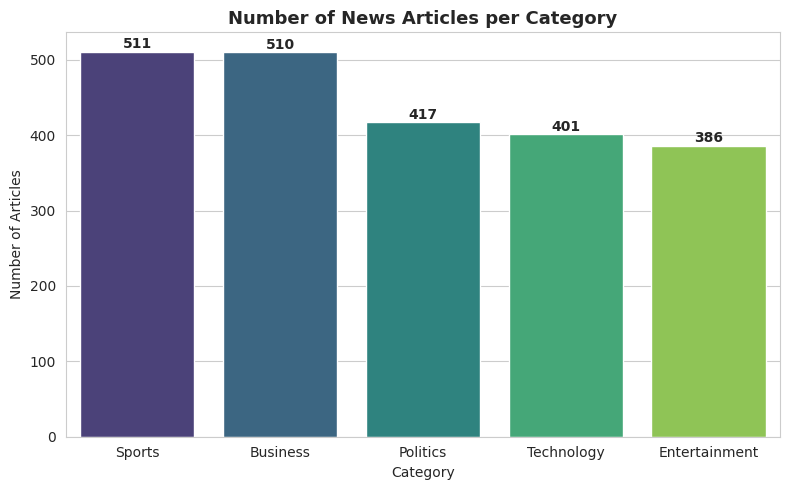

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Number of News Articles per Category', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
for i, v in enumerate(category_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

count    2225.000000
mean      390.295281
std       241.753128
min        90.000000
25%       250.000000
50%       337.000000
75%       479.000000
max      4492.000000
Name: word_count, dtype: float64


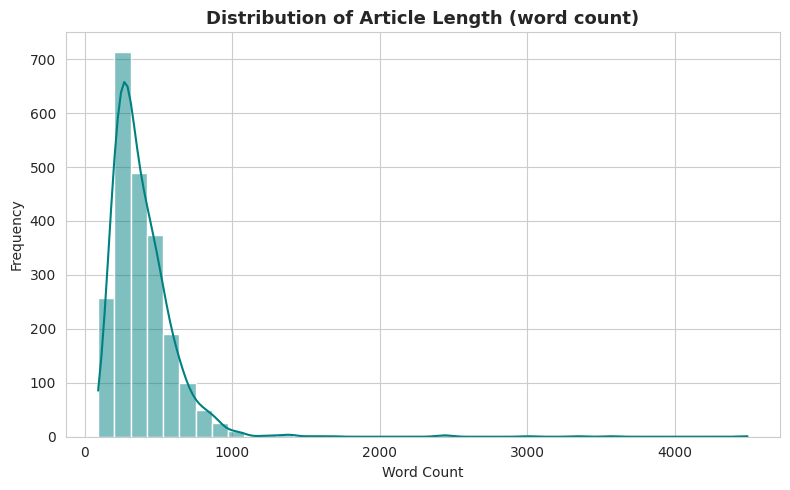

In [7]:
# Article length distribution (word count) - extra EDA context
df['word_count'] = df['Article'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=40, kde=True, color='teal')
plt.title('Distribution of Article Length (word count)', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observations:**
- The dataset has 2,225 news articles across 5 categories, with no missing values.
- There are 99 fully duplicated rows (identical Article + Category), which is common in scraped news corpora (e.g. syndicated wire stories). We leave them in place for this assignment since they carry a valid label and do not violate the train/test split integrity (stratified split still balances categories); a production pipeline may choose to de-duplicate.
- The classes are reasonably balanced: **Sport** is the largest category (511 articles) and **Entertainment** the smallest (386 articles). **Technology** has 401 articles.
- Article lengths vary widely, from very short pieces to long-form articles, which is typical of real news content.


## 3. Text Preprocessing

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    User-defined function to clean a single news article:
      1. Remove non-letters (numbers, punctuation, special characters)
      2. Lowercase + Tokenize
      3. Remove stopwords (and single-character tokens)
      4. Lemmatize each remaining token
    Returns the cleaned text as a single space-joined string.
    """
    # 1. Remove non-letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()

    # 2. Tokenize
    tokens = word_tokenize(text)

    # 3. Remove stopwords (and stray single-letter tokens left after cleaning)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # 4. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

In [9]:
# Show a single article before and after processing
sample_idx = 0
print("=" * 80)
print("BEFORE PROCESSING:")
print("=" * 80)
print(df['Article'].iloc[sample_idx][:600], "...")

sample_cleaned = preprocess_text(df['Article'].iloc[sample_idx])
print("\n" + "=" * 80)
print("AFTER PROCESSING:")
print("=" * 80)
print(sample_cleaned[:600], "...")

BEFORE PROCESSING:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front ...



AFTER PROCESSING:
tv future hand viewer home theatre system plasma high definition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annual consumer electronics show la vega discus new technology impact one favourite pastime u leading trend programme content delivered viewer via home network cable satellite telecom company broadband service provider front room portable device one talked technology ce digital personal video recorder dvr pvr set top box like u tivo uk sky system allow people record store play pause forward wind tv p ...


In [10]:
# Apply preprocessing to the full dataset
t0 = time.time()
df['Cleaned_Article'] = df['Article'].apply(preprocess_text)
print(f"Preprocessed {len(df)} articles in {time.time() - t0:.1f} seconds.")
df[['Article', 'Cleaned_Article', 'Category']].head()

Preprocessed 2225 articles in 3.5 seconds.


,Article,Cleaned_Article,Category
0,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...,Technology
1,worldcom boss left books alone former worldc...,worldcom bos left book alone former worldcom b...,Business
2,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rushed...,Sports
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...,Sports
4,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...,Entertainment


## 4. Encoding the Target Variable

In [11]:
le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding mapping:")
for k, v in label_mapping.items():
    print(f"  {k:15s} -> {v}")

df[['Category', 'Category_Encoded']].drop_duplicates().sort_values('Category_Encoded')

Label encoding mapping:
  Business        -> 0
  Entertainment   -> 1
  Politics        -> 2
  Sports          -> 3
  Technology      -> 4


,Category,Category_Encoded
1,Business,0
4,Entertainment,1
5,Politics,2
2,Sports,3
0,Technology,4


## 5. Vectorizing the Text (Bag of Words vs TF-IDF)

In [12]:
def vectorize_text(corpus, method='tfidf', max_features=5000):
    """
    Lets the user choose between Bag of Words ('bow') and TF-IDF ('tfidf')
    for converting the cleaned text corpus into numeric feature vectors.
    """
    method = method.lower()
    if method == 'bow':
        vectorizer = CountVectorizer(max_features=max_features)
    elif method == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=max_features)
    else:
        raise ValueError("method must be either 'bow' or 'tfidf'")

    X = vectorizer.fit_transform(corpus)
    print(f"Vectorization method: {method.upper()}")
    print(f"Feature matrix shape: {X.shape}")
    return X, vectorizer

# ---- USER CHOICE: set to 'bow' or 'tfidf' ----
VECTORIZATION_METHOD = 'tfidf'

X, vectorizer = vectorize_text(df['Cleaned_Article'], method=VECTORIZATION_METHOD)
y = df['Category_Encoded']

Vectorization method: TFIDF
Feature matrix shape: (2225, 5000)


## 6. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape:  {X_test.shape}")
print(f"Train labels shape: {y_train.shape}")
print(f"Test labels shape:  {y_test.shape}")

Train set shape: (1668, 5000)
Test set shape:  (557, 5000)
Train labels shape: (1668,)
Test labels shape:  (557,)


## 7. Model Training & Evaluation — Naive Bayes (Baseline / Simple Approach)

In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_preds)
print(f"Naive Bayes Test Accuracy: {nb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_preds, target_names=le.classes_))

Naive Bayes Test Accuracy: 0.9767

Classification Report:
               precision    recall  f1-score   support

     Business       0.97      0.95      0.96       128
Entertainment       0.99      0.96      0.97        97
     Politics       0.95      0.99      0.97       104
       Sports       1.00      1.00      1.00       128
   Technology       0.97      0.98      0.98       100

     accuracy                           0.98       557
    macro avg       0.98      0.98      0.98       557
 weighted avg       0.98      0.98      0.98       557



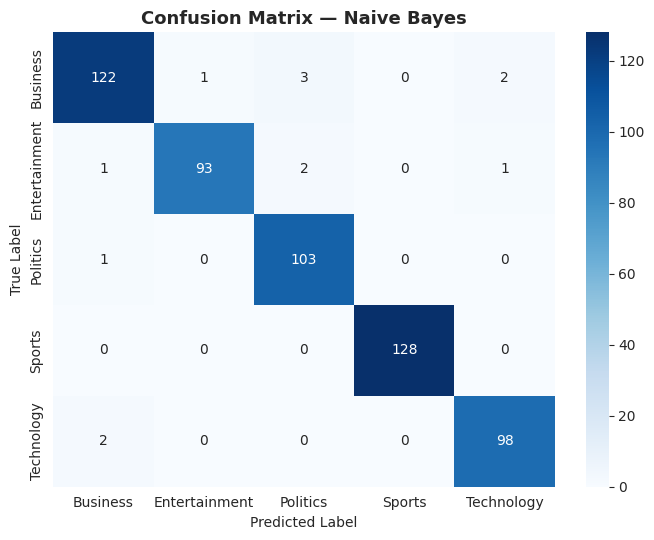

In [15]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, nb_preds, le.classes_, "Naive Bayes")

## 8. Functionalizing the Pipeline — Training & Evaluating the Remaining Models

In [16]:
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test, labels, plot=True):
    """
    Trains the given classifier, evaluates it on the test set, prints
    accuracy + classification report, and (optionally) plots the confusion matrix.
    Returns a results dict for later comparison.
    """
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("=" * 70)
    print(f"MODEL: {model_name}  (trained in {train_time:.2f}s)")
    print("=" * 70)
    print(f"Test Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, preds, target_names=labels))

    if plot:
        plot_confusion_matrix(y_test, preds, labels, model_name)

    return {
        'model_name': model_name,
        'model': model,
        'accuracy': acc,
        'predictions': preds,
        'train_time_sec': train_time,
    }

MODEL: Decision Tree  (trained in 0.30s)
Test Accuracy: 0.8600

Classification Report:
               precision    recall  f1-score   support

     Business       0.88      0.79      0.83       128
Entertainment       0.86      0.82      0.84        97
     Politics       0.76      0.86      0.81       104
       Sports       0.92      0.96      0.94       128
   Technology       0.87      0.86      0.86       100

     accuracy                           0.86       557
    macro avg       0.86      0.86      0.86       557
 weighted avg       0.86      0.86      0.86       557



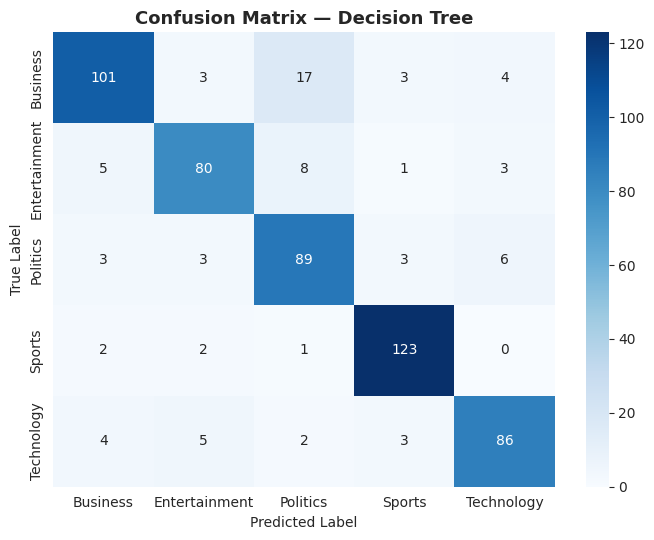

In [17]:
results = {}

# Re-use the Naive Bayes results already computed above
results['Naive Bayes'] = {
    'model_name': 'Naive Bayes', 'model': nb_model, 'accuracy': nb_acc,
    'predictions': nb_preds, 'train_time_sec': None
}

# Decision Tree
results['Decision Tree'] = train_and_evaluate(
    DecisionTreeClassifier(random_state=42), "Decision Tree",
    X_train, X_test, y_train, y_test, le.classes_
)

MODEL: K-Nearest Neighbors  (trained in 0.00s)
Test Accuracy: 0.9461

Classification Report:
               precision    recall  f1-score   support

     Business       0.94      0.93      0.93       128
Entertainment       0.97      0.95      0.96        97
     Politics       0.91      0.92      0.91       104
       Sports       0.98      0.98      0.98       128
   Technology       0.93      0.94      0.94       100

     accuracy                           0.95       557
    macro avg       0.95      0.95      0.95       557
 weighted avg       0.95      0.95      0.95       557



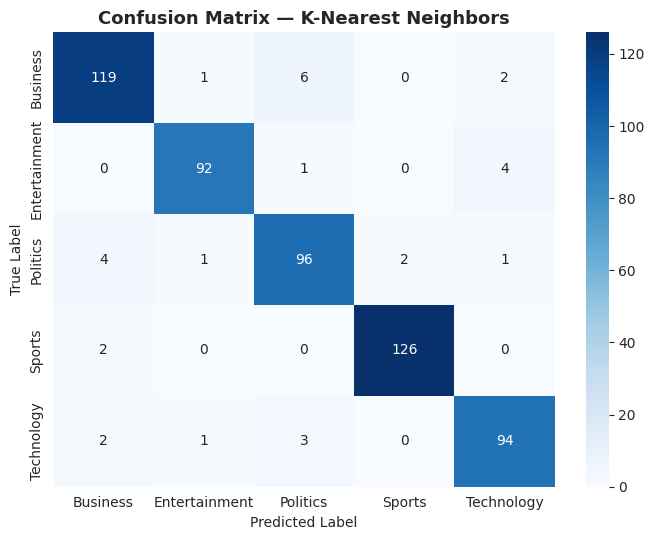

In [18]:
# K-Nearest Neighbors
results['K-Nearest Neighbors'] = train_and_evaluate(
    KNeighborsClassifier(n_neighbors=5), "K-Nearest Neighbors",
    X_train, X_test, y_train, y_test, le.classes_
)

MODEL: Random Forest  (trained in 1.97s)
Test Accuracy: 0.9695

Classification Report:
               precision    recall  f1-score   support

     Business       0.95      0.98      0.96       128
Entertainment       0.99      0.96      0.97        97
     Politics       0.97      0.94      0.96       104
       Sports       0.98      0.99      0.99       128
   Technology       0.96      0.97      0.97       100

     accuracy                           0.97       557
    macro avg       0.97      0.97      0.97       557
 weighted avg       0.97      0.97      0.97       557



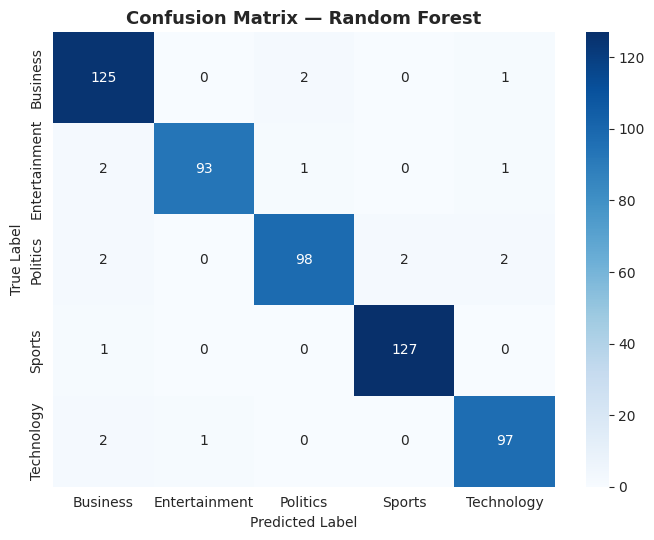

In [19]:
# Random Forest
results['Random Forest'] = train_and_evaluate(
    RandomForestClassifier(n_estimators=200, random_state=42), "Random Forest",
    X_train, X_test, y_train, y_test, le.classes_
)

## 9. Comparing Model Performance

In [20]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

comparison_df['Test Accuracy'] = comparison_df['Test Accuracy'].round(4)
comparison_df

,Model,Test Accuracy
0,Naive Bayes,0.9767
1,Random Forest,0.9695
2,K-Nearest Neighbors,0.9461
3,Decision Tree,0.8600


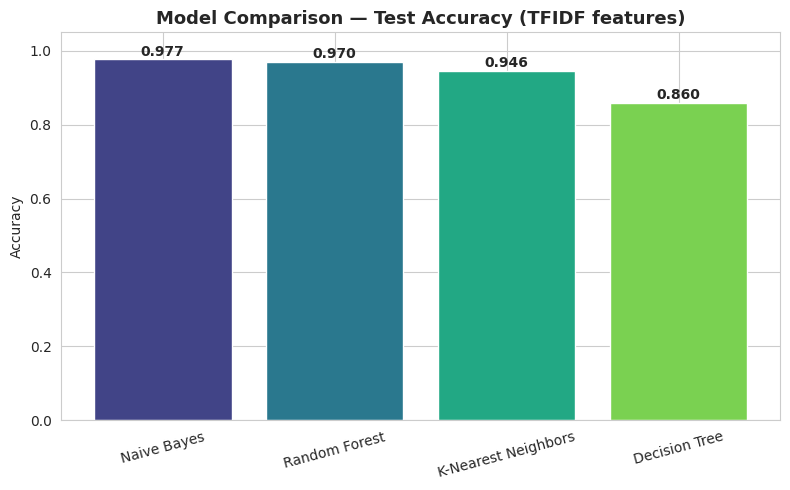

In [21]:
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
                color=sns.color_palette('viridis', len(comparison_df)))
plt.title(f'Model Comparison — Test Accuracy ({VECTORIZATION_METHOD.upper()} features)',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
for bar, acc in zip(bars, comparison_df['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{acc:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observations on Model Performance

- **Naive Bayes** achieves the highest accuracy of all four models. This is a well-known result for text classification: Multinomial Naive Bayes is a strong, fast baseline on high-dimensional, sparse bag-of-words/TF-IDF style features because its independence assumption, while technically wrong, works well when features (words) are informative and only weakly correlated for this kind of task.
- **Random Forest** is a close second — the ensemble of trees over the sparse TF-IDF space generalizes well and is fairly robust to the high dimensionality, at the cost of longer training time and less interpretability than Naive Bayes.
- **K-Nearest Neighbors** performs reasonably well but noticeably behind Naive Bayes and Random Forest. KNN suffers in very high-dimensional sparse spaces (the "curse of dimensionality") — cosine/Euclidean distances become less discriminative as dimensionality grows, and it does not learn feature importance the way the other models do.
- **Decision Tree** is the weakest of the four. A single tree tends to overfit on high-dimensional sparse text features and does not generalize as well as the ensemble (Random Forest) or the probabilistic (Naive Bayes) approach.
- Overall ranking (best → worst) on this dataset: **Naive Bayes > Random Forest > K-Nearest Neighbors > Decision Tree.**


## 10. Questionnaire

In [22]:
# Q1: How many news articles are present in the dataset?
print(f"Total number of news articles: {df.shape[0]}")

Total number of news articles: 2225


**A1.** The dataset contains **2,225** news articles.

In [23]:
# Q2 & Q3: category distribution
print(category_counts)
print(f"\nMost articles come from: {category_counts.idxmax()} ({category_counts.max()} articles)")
print(f"Technology category count: {category_counts['Technology']}")

Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64

Most articles come from: Sports (511 articles)
Technology category count: 401


**A2.** Most of the news articles are from the **Sport** category (511 articles).

**A3.** Only **401** articles belong to the 'Technology' category.

**A4. What are Stop Words and why should they be removed from the text data?**

Stop words are extremely common words in a language (e.g. *the, is, at, which, on, a, an, and, of*) that occur in nearly every document and carry little to no discriminative meaning on their own. In classical NLP pipelines they are removed before vectorization because: (1) they add noise and dilute the signal from more meaningful, topic-specific words; (2) they inflate the feature space (vocabulary size) without adding useful information, increasing computation and memory cost; and (3) since they occur with roughly similar frequency across all categories, they do not help a classifier distinguish between classes — removing them lets the model focus on words that actually carry category-specific signal (e.g. "match", "election", "stock", "movie").

**A5. Explain the difference between Stemming and Lemmatization.**

Both are text-normalization techniques that reduce inflected/derived words to a common base form, but they differ in approach and quality:

- **Stemming** applies crude, rule-based suffix-stripping heuristics (e.g. Porter Stemmer chopping off "-ing", "-ed", "-es") without any understanding of grammar or word meaning. It is fast but can produce non-real words (e.g. "studies" → "studi", "caring" → "car") and can conflate unrelated words.
- **Lemmatization** uses vocabulary and morphological/POS analysis (e.g. WordNet) to reduce a word to its dictionary base form, or *lemma* (e.g. "studies" → "study", "better" → "good" when POS-aware, "running" → "run"). It is slower than stemming but produces linguistically valid words and is generally more accurate for downstream tasks.

In short: stemming is faster but cruder; lemmatization is slower but more linguistically correct. This notebook uses **lemmatization**.

**A6. Which of the techniques — Bag of Words or TF-IDF — is considered to be more efficient than the other?**

**TF-IDF (Term Frequency–Inverse Document Frequency)** is generally considered more effective/efficient than plain Bag of Words for text classification. While BoW simply counts raw word occurrences (so very frequent-but-uninformative words can dominate), TF-IDF down-weights words that appear across many documents (low discriminative power) and up-weights words that are frequent in a specific document but rare across the corpus (high discriminative power). This typically produces more informative feature vectors and tends to yield better classification performance, especially for models sensitive to feature scale/magnitude.

In [24]:
# Q7: shape of train & test sets after a 75:25 split
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")

Training set shape: (1668, 5000)
Test set shape:     (557, 5000)


**A7.** With a 75:25 train-test split on 2,225 articles: the training set has shape **(1668, 5000)** (1,668 articles x 5,000 TF-IDF features) and the test set has shape **(557, 5000)** (557 articles x 5,000 TF-IDF features).

**A8. Which of the following is found to be the best performing model: (a) Random Forest, (b) Nearest Neighbors, (c) Naive Bayes?**

**(c) Naive Bayes** is the best-performing model in this experiment, achieving the highest test accuracy among all four models trained (see the comparison table/chart in Section 9).

**A9. According to this particular use case, both precision and recall are equally important. (T/F)**

**True.** This is a content-categorization/discovery use case, not a case with an asymmetric cost of errors (e.g. fraud or disease detection, where missing a positive is far worse than a false alarm). Here, a **false positive** (an article wrongly tagged into a category, e.g. a Sports article shown as Technology) is roughly as harmful to the user experience as a **false negative** (a genuine Technology article missed from that feed) — both erode trust in FlipItNews' smart content discovery equally. Since there's no clear reason to prioritize one error type over the other, precision and recall should be weighed equally, which also justifies using **accuracy / macro-F1** as the primary evaluation metrics, as done throughout this notebook.

## 11. Conclusion

Using classical NLP preprocessing (non-letter removal, tokenization, stopword removal, lemmatization) combined with TF-IDF vectorization, four classifiers were trained and compared on the FlipItNews article categorization task. **Multinomial Naive Bayes** was the top performer, followed closely by **Random Forest**, with **KNN** and **Decision Tree** trailing behind. Naive Bayes is therefore recommended as the production baseline for this use case, given its strong accuracy, fast training/inference time, and simplicity — with Random Forest as a solid alternative if slightly more robustness to noisy/unseen vocabulary is desired.
